#### Assignment 8: Supervised Learning Classification

#### Alyssa Iapalucci
#### Google Colab Link: https://colab.research.google.com/drive/10iJyuUR9a3FWlJ5hrfvwv7JK6xPwGS9f?usp=sharing
#### Github Link:

# Travel Cost Classification Project

This project uses machine learning classification models to predict travel cost categories (Low, Medium, High) based on travel-related features such as accommodation cost, transportation cost, age, and destination.

In [5]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay

In [16]:
# Load Dataset

df = pd.read_csv("Travel details dataset.csv")

df.columns = df.columns.str.strip()
df.head()

,Trip ID,Destination,Start date,End date,Duration (days),Traveler name,Traveler age,Traveler gender,Traveler nationality,Accommodation type,Accommodation cost,Transportation type,Transportation cost
0,1,"London, UK",5/1/2023,5/8/2023,7.0,John Smith,35.0,Male,American,Hotel,1200,Flight,600
1,2,"Phuket, Thailand",6/15/2023,6/20/2023,5.0,Jane Doe,28.0,Female,Canadian,Resort,800,Flight,500
2,3,"Bali, Indonesia",7/1/2023,7/8/2023,7.0,David Lee,45.0,Male,Korean,Villa,1000,Flight,700
3,4,"New York, USA",8/15/2023,8/29/2023,14.0,Sarah Johnson,29.0,Female,British,Hotel,2000,Flight,1000
4,5,"Tokyo, Japan",9/10/2023,9/17/2023,7.0,Kim Nguyen,26.0,Female,Vietnamese,Airbnb,700,Train,200


In [17]:
# Basic Info + Cleaning

print(df.info())
print(df.isnull().sum())

# Remove duplicates
df = df.drop_duplicates()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139 entries, 0 to 138
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Trip ID               139 non-null    int64  
 1   Destination           137 non-null    object 
 2   Start date            137 non-null    object 
 3   End date              137 non-null    object 
 4   Duration (days)       137 non-null    float64
 5   Traveler name         137 non-null    object 
 6   Traveler age          137 non-null    float64
 7   Traveler gender       137 non-null    object 
 8   Traveler nationality  137 non-null    object 
 9   Accommodation type    137 non-null    object 
 10  Accommodation cost    137 non-null    object 
 11  Transportation type   136 non-null    object 
 12  Transportation cost   136 non-null    object 
dtypes: float64(2), int64(1), object(10)
memory usage: 14.2+ KB
None
Trip ID                 0
Destination             2
Start dat

In [18]:
# Handle Missing Values

num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

In [19]:
# Ensure Numeric Costs

df["Accommodation cost"] = pd.to_numeric(df["Accommodation cost"], errors="coerce")
df["Transportation cost"] = pd.to_numeric(df["Transportation cost"], errors="coerce")

df["Accommodation cost"] = df["Accommodation cost"].fillna(df["Accommodation cost"].median())
df["Transportation cost"] = df["Transportation cost"].fillna(df["Transportation cost"].median())

In [20]:
# Feature Engineering (Total Cost)

df["Total_Cost"] = df["Accommodation cost"] + df["Transportation cost"]

In [21]:
# Create Classification Target

df["Cost_Category"] = pd.cut(
    df["Total_Cost"],
    bins=3,
    labels=["Low", "Medium", "High"]
)

In [22]:
# Drop unnecessary columns

df = df.drop(["Total_Cost", "Trip ID", "Traveler name"], axis=1)

In [23]:
# Encode categorical variables

label_encoders = {}

for col in df.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [24]:
# Split data

X = df.drop("Cost_Category", axis=1)
y = df["Cost_Category"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [25]:
# Scale features

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

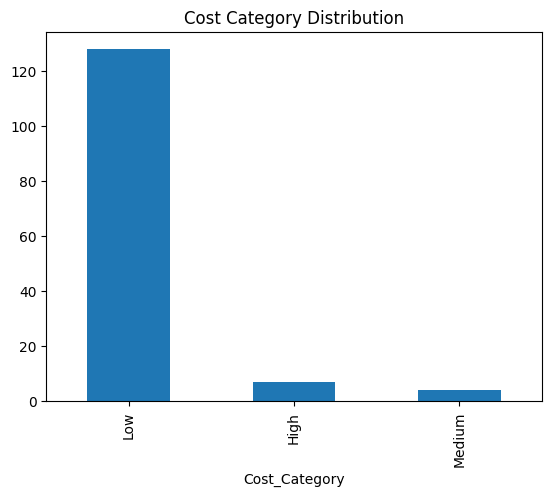

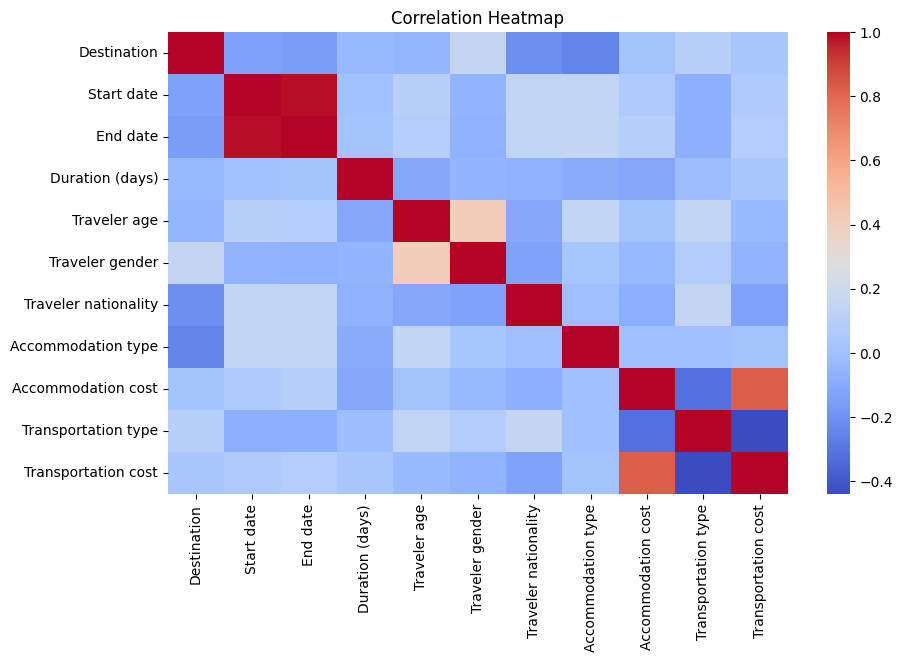

In [32]:
# EDA

# Distribution
df["Cost_Category"].value_counts().plot(kind="bar")
plt.title("Cost Category Distribution")
plt.show()

# Correlation
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [28]:
# Models

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# SVM
svm = SVC()
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)

# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)

In [29]:
# Evaluation Function

def evaluate(name, y_test, y_pred):
    print("\n", name)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, average="weighted"))
    print("Recall:", recall_score(y_test, y_pred, average="weighted"))
    print("F1:", f1_score(y_test, y_pred, average="weighted"))
    print(confusion_matrix(y_test, y_pred))


In [30]:
# Run Evaluation

evaluate("Logistic Regression", y_test, lr_pred)
evaluate("Random Forest", y_test, rf_pred)
evaluate("SVM", y_test, svm_pred)
evaluate("KNN", y_test, knn_pred)


 Logistic Regression
Accuracy: 0.9642857142857143
Precision: 0.9298941798941798
Recall: 0.9642857142857143
F1: 0.9467654986522911
[[ 1  0  0]
 [ 0 26  0]
 [ 0  1  0]]

 Random Forest
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0
[[ 1  0  0]
 [ 0 26  0]
 [ 0  0  1]]

 SVM
Accuracy: 0.9285714285714286
Precision: 0.8622448979591837
Recall: 0.9285714285714286
F1: 0.8941798941798941
[[ 0  1  0]
 [ 0 26  0]
 [ 0  1  0]]

 KNN
Accuracy: 0.9642857142857143
Precision: 0.9298941798941798
Recall: 0.9642857142857143
F1: 0.9467654986522911
[[ 1  0  0]
 [ 0 26  0]
 [ 0  1  0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
